# RLB-DP Bidder Testing

This notebook tests the trained RLB-DP bidder on campaigns.

**Prerequisites:** Run `python train_rlb_dp.py` first to create the model!

## What we'll do:
1. Load the trained value function
2. Test on a single campaign with detailed visualization
3. Evaluate on all campaigns with metrics (MCR, RMSE_T)

In [1]:
import sys
sys.path.append("../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from simulator.simulation.modules import Campaign, History
from simulator.simulation.simulate import simulate_campaign
from simulator.simulation.utils_visualization import data_prep_vis, plot_history_article
from simulator.model.rlb_dp_bidder import RLBDPBidder
from simulator.validation.check_results import autobidder_check

## Load Data and Model

In [2]:
# Load data
auction_mode = 'FPA'
campaigns_path = '../data/small_example/fpa/subsample_campaigns.csv'
stats_path = '../data/small_example/fpa/subsample_stats.csv'

campaign_df = pd.read_csv(campaigns_path)
stats_df = pd.read_csv(stats_path)

print(f"Loaded {len(campaign_df)} campaigns")
print(f"Loaded {len(stats_df):,} stat records")

Loaded 10000 campaigns
Loaded 9,210,861 stat records


In [3]:
# Load trained model
model_path = '../data/rlb_dp_model.pkl'

try:
    with open(model_path, 'rb') as f:
        model_data = pickle.load(f)
    
    print("✓ Model loaded successfully!")
    print(f"  Type: {model_data['type']}")
    print(f"  N_bound (max hours): {model_data['N_bound']}")
    print(f"  B_bound (max budget): ${model_data['B_bound']}")
    print(f"  Value table shape: {model_data['table'].shape}")
    
    # Show some sample values
    V = model_data['table']
    print(f"\nSample values:")
    print(f"  V(1 hour, $1000) = {V[1][1000]:.2f} expected clicks")
    # print(f"  V(10 hours, $5000) = {V[10][5000]:.2f} expected clicks")
    if V.shape[0] > 50 and V.shape[1] > 10000:
        print(f"  V(50 hours, $10000) = {V[50][10000]:.2f} expected clicks")
    
except FileNotFoundError:
    print("❌ Model not found!")
    print("Please run: python train_rlb_dp.py")
    raise

✓ Model loaded successfully!
  Type: table
  N_bound (max hours): 100
  B_bound (max budget): $1885
  Value table shape: (101, 1886)

Sample values:
  V(1 hour, $1000) = 11.63 expected clicks


## Test on Single Campaign

Let's test the RLB-DP bidder on one campaign and visualize the results.

In [7]:
# Pick a campaign to test
CAMPAIGN_IDX = 25  # You can change this

campaign_data = campaign_df.iloc[CAMPAIGN_IDX]

print(f"Campaign {campaign_data['campaign_id']}:")
print(f"  Budget: ${campaign_data['auction_budget']:.2f}")
print(f"  Duration: {(campaign_data['campaign_end'] - campaign_data['campaign_start'])/3600:.1f} hours")
print(f"  Category: {campaign_data['logical_category']}")
print(f"  Region: {campaign_data['region_id']}")

Campaign 86755692:
  Budget: $195.84
  Duration: 24.0 hours
  Category: 5.26
  Region: 643030


In [8]:
# Create campaign object
campaign_example = Campaign(
    item_id=campaign_data['item_id'],
    campaign_id=int(campaign_data['campaign_id']),
    loc_id=int(campaign_data["loc_id"]),
    region_id=int(campaign_data["region_id"]),
    logical_category=campaign_data["logical_category"],
    microcat_ext=int(campaign_data["microcat_ext"]),
    campaign_start=int(campaign_data["campaign_start"]),
    campaign_end=int(campaign_data["campaign_end"]),
    initial_balance=campaign_data['auction_budget'],
    balance=campaign_data['auction_budget'],
    curr_time=int(campaign_data["campaign_start"]),
    prev_time=int(campaign_data["campaign_start"]),
    prev_balance=campaign_data['auction_budget'],
)

In [9]:
# Create RLB-DP bidder
rlb_bidder = RLBDPBidder(params={
    'model_path': model_path,
    'max_bid': 300,
})

print("✓ RLB-DP bidder created")

✓ RLB-DP bidder created


In [10]:
# Run simulation
print("Running simulation...")
simulation_history = simulate_campaign(
    campaign=campaign_example,
    bidder=rlb_bidder,
    stats_file=stats_df,
    auction_mode=auction_mode
)
print("✓ Simulation complete!")

Running simulation...
✓ Simulation complete!


### Results Summary

In [11]:
# Get results
df = simulation_history.to_data_frame()

final_clicks = df['clicks'].iloc[-1]
final_balance = df['balance'].iloc[-1]
total_spend = campaign_data['auction_budget'] - final_balance
budget_utilization = total_spend / campaign_data['auction_budget'] * 100

print("="*60)
print("CAMPAIGN RESULTS")
print("="*60)
print(f"Initial budget:       ${campaign_data['auction_budget']:.2f}")
print(f"Total spend:          ${total_spend:.2f}")
print(f"Final balance:        ${final_balance:.2f}")
print(f"Budget utilization:   {budget_utilization:.1f}%")
print()
print(f"Total clicks:         {final_clicks:.2f}")

if total_spend > 0 and final_clicks > 0:
    cost_per_click = total_spend / final_clicks
    print(f"Cost per click:       ${cost_per_click:.2f}")

print()
print(f"Simulation steps:     {len(df)}")
print(f"Average bid:          ${df['bid'].mean():.2f}")
print(f"Min bid:              ${df['bid'].min():.2f}")
print(f"Max bid:              ${df['bid'].max():.2f}")

CAMPAIGN RESULTS
Initial budget:       $195.84
Total spend:          $38.29
Final balance:        $157.55
Budget utilization:   19.6%

Total clicks:         42.41
Cost per click:       $0.90

Simulation steps:     25
Average bid:          $30.44
Min bid:              $10.00
Max bid:              $157.00


### Visualization

Visualize how the bidder behaved during the campaign.

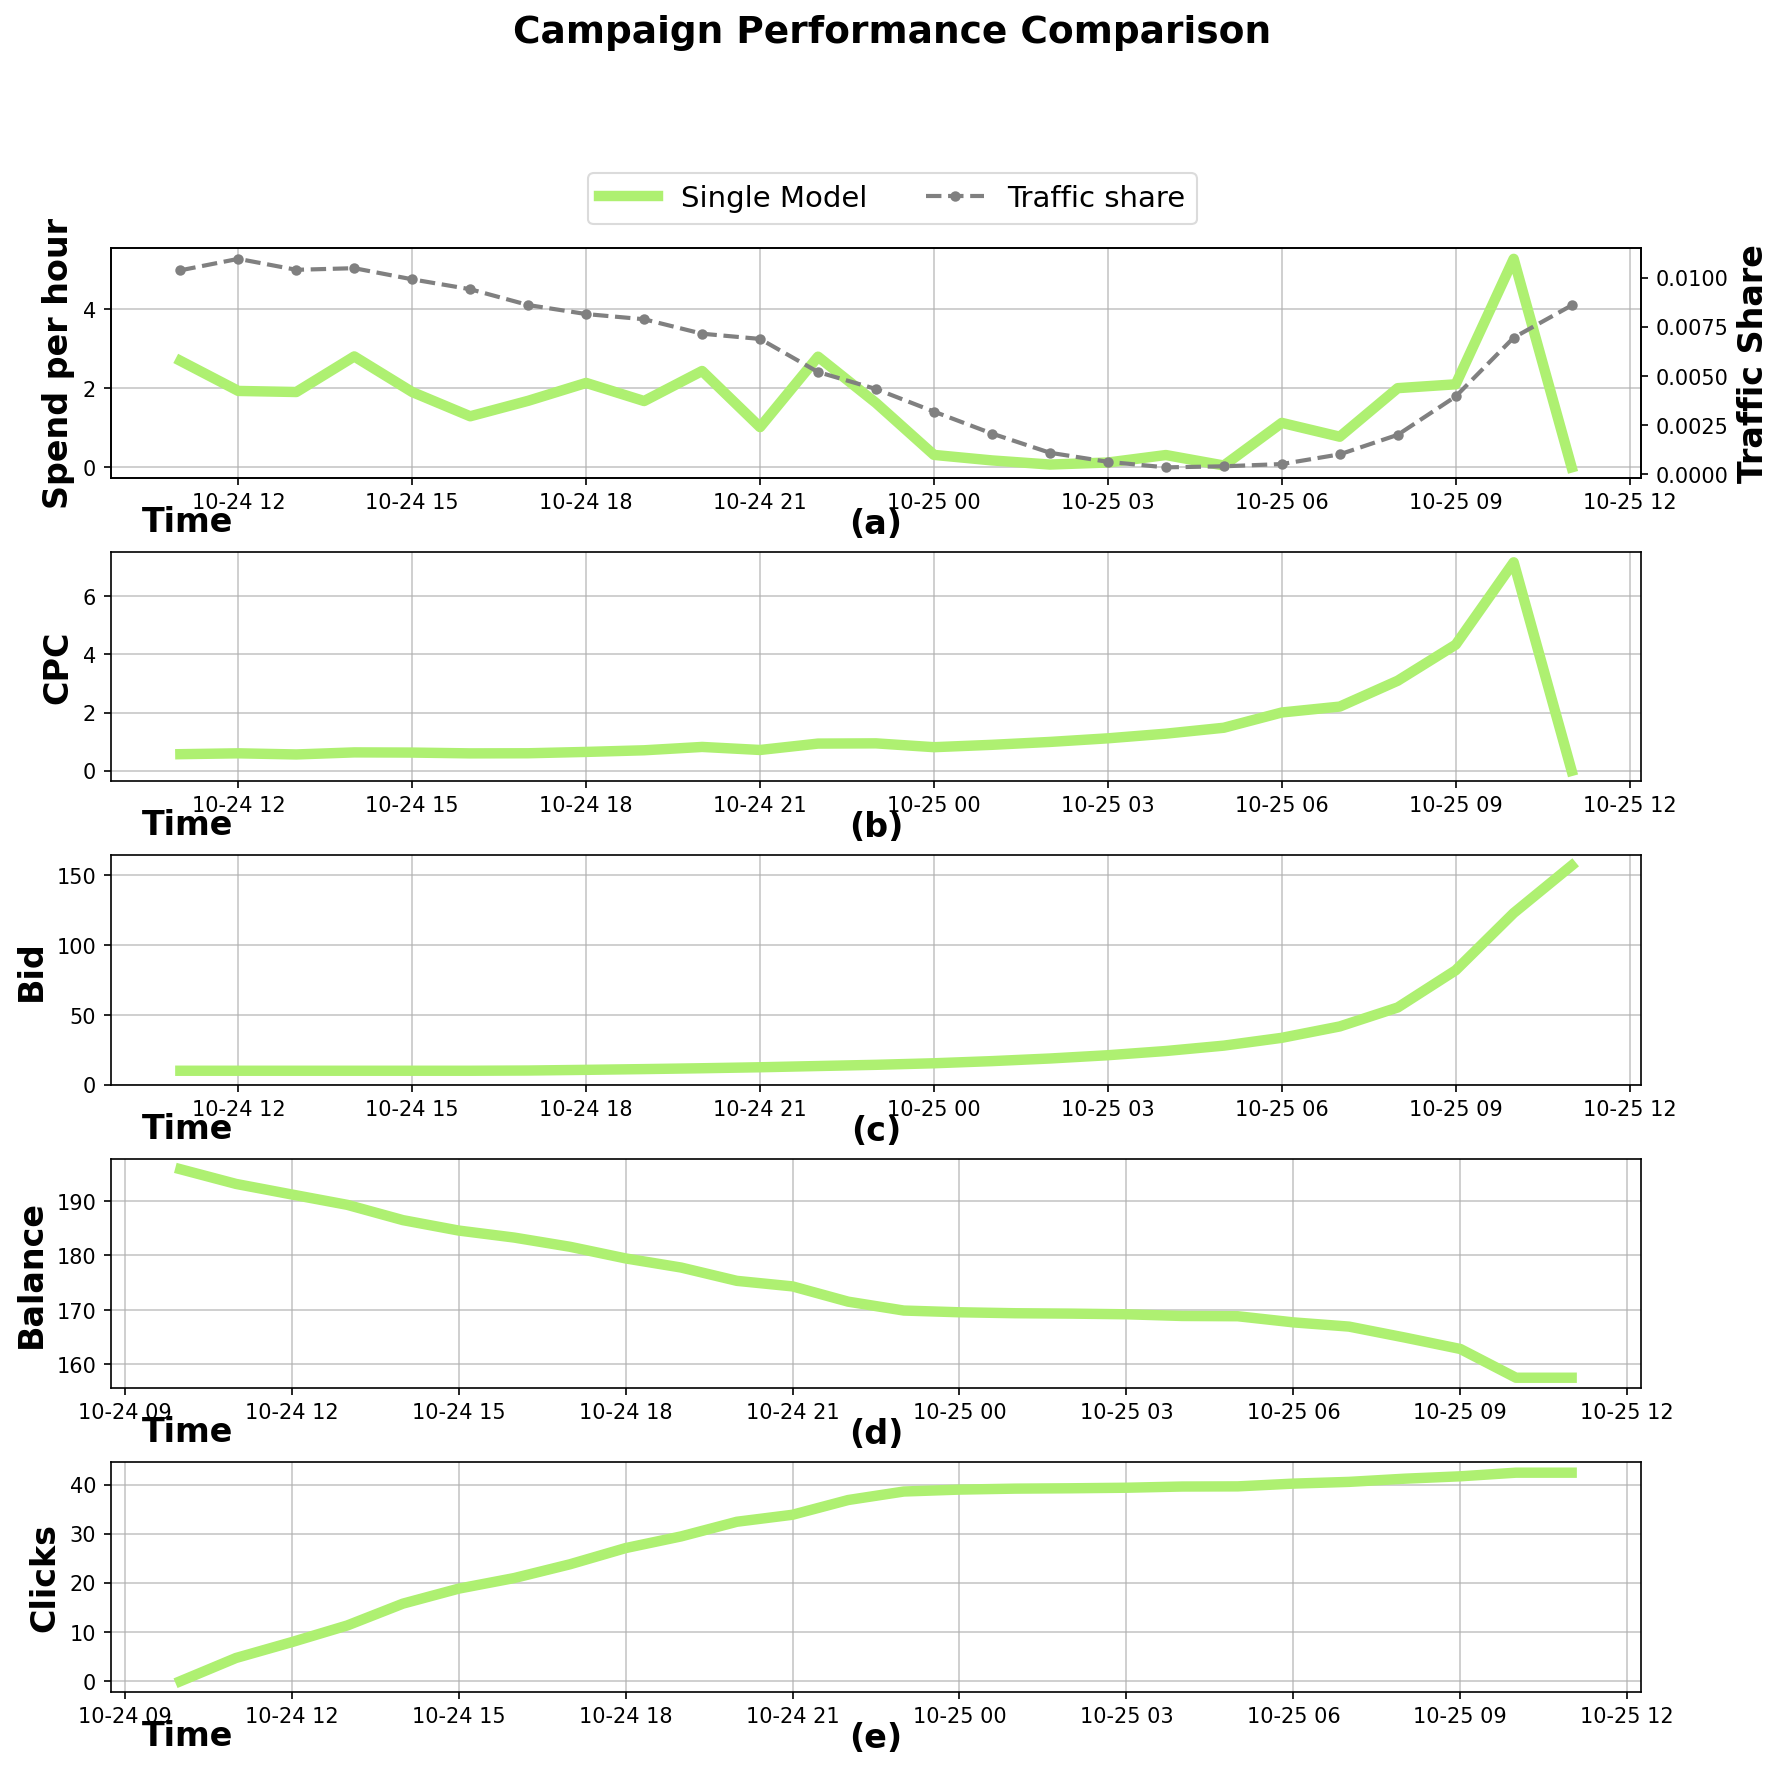

<Figure size 640x480 with 0 Axes>

In [12]:
# Prepare visualization data
vis_data = data_prep_vis(df)

# Plot campaign history
fig = plot_history_article(vis_data)
plt.suptitle(f'RLB-DP Bidder - Campaign {campaign_data["campaign_id"]}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

> USCB (посмотреть) препринт с этим
> посмотреть как через Q функцию зайти
(это для сравнения, можно ли сравнить с тюниным RLB)

<br

> Нужно посмотреть как тюнятся контроллеры (PID) и на тех же данных получить V функция (RLB) и сравнить на инференесы
>
<br>

Q-функция vs Таблица (если RL победит бейзлайн)
<br>
Сравнение на 2 сценариях
Out of table и внутри state таблицы


### Additional Analysis

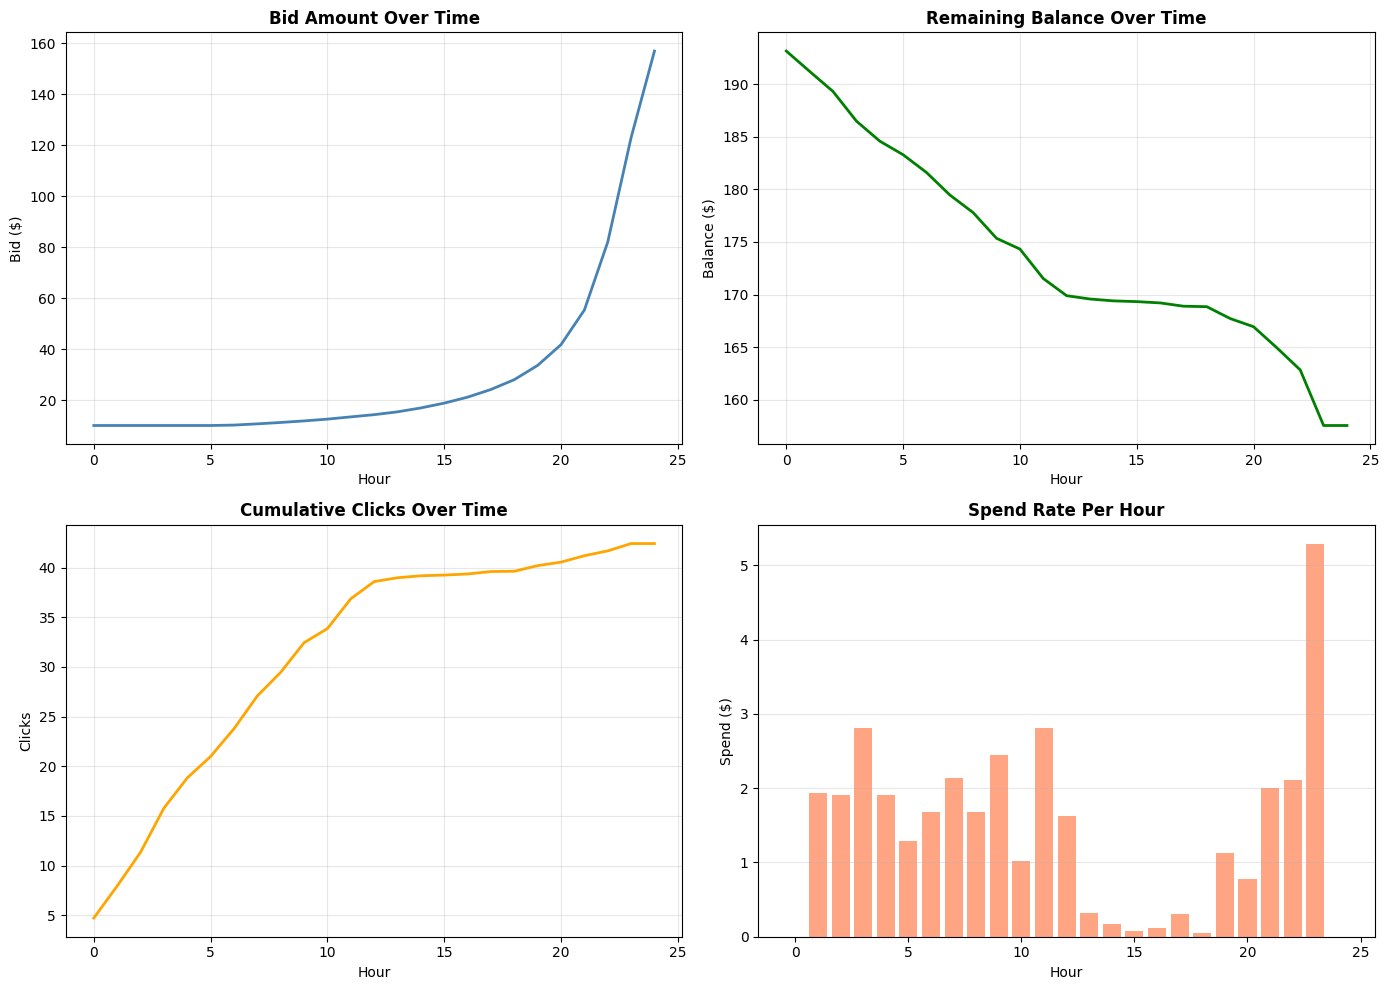

In [13]:
# Plot bid evolution and clicks over time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Bid over time
axes[0, 0].plot(df.index, df['bid'], linewidth=2, color='steelblue')
axes[0, 0].set_title('Bid Amount Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Bid ($)')
axes[0, 0].grid(True, alpha=0.3)

# Balance over time
axes[0, 1].plot(df.index, df['balance'], linewidth=2, color='green')
axes[0, 1].set_title('Remaining Balance Over Time', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Balance ($)')
axes[0, 1].grid(True, alpha=0.3)

# Cumulative clicks
axes[1, 0].plot(df.index, df['clicks'], linewidth=2, color='orange')
axes[1, 0].set_title('Cumulative Clicks Over Time', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Clicks')
axes[1, 0].grid(True, alpha=0.3)

# Spend rate
spend_per_hour = df['initial_balance'] - df['balance']
spend_rate = spend_per_hour.diff().fillna(0)
axes[1, 1].bar(df.index, spend_rate, color='coral', alpha=0.7)
axes[1, 1].set_title('Spend Rate Per Hour', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Spend ($)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Evaluate on All Campaigns

Now let's test the RLB-DP bidder on all campaigns and compute aggregate metrics.

In [14]:
print("Running evaluation on all campaigns...")
print("This may take a few minutes...\n")

results = autobidder_check(
    bidder=RLBDPBidder,
    params={
        "input_campaigns": campaigns_path,
        "input_stats": stats_path,
        'model_path': model_path,
        'max_bid': 300,
    },
    auction_mode=auction_mode
)

print("\n✓ Evaluation complete!")

Running evaluation on all campaigns...
This may take a few minutes...


✓ Evaluation complete!


### Overall Metrics

In [15]:
print("="*60)
print("RLB-DP BIDDER PERFORMANCE")
print("="*60)
print(f"Number of campaigns: {len(campaign_df)}")
print()
print("METRICS:")
print(f"  MCR (Money Consumption Ratio): {results['score'][0]:.4f}")
print(f"  RMSE_T (Time RMSE):            {results['score'][1]:.4f}")
print()
print("INTERPRETATION:")
print("  MCR close to 0: Perfect budget utilization")
print("  MCR < 0.2:      Excellent (within 20% of target)")
print("  MCR < 0.5:      Good")
print("  MCR > 1.0:      Poor (significant over/underspend)")
print()
print("  RMSE_T close to 0: Perfect smooth pacing")
print("  RMSE_T < 1.5:      Good (smooth spending)")
print("  RMSE_T > 3.0:      Poor (jerky spending pattern)")

RLB-DP BIDDER PERFORMANCE
Number of campaigns: 10000

METRICS:
  MCR (Money Consumption Ratio): 0.6293
  RMSE_T (Time RMSE):            1.3933

INTERPRETATION:
  MCR close to 0: Perfect budget utilization
  MCR < 0.2:      Excellent (within 20% of target)
  MCR < 0.5:      Good
  MCR > 1.0:      Poor (significant over/underspend)

  RMSE_T close to 0: Perfect smooth pacing
  RMSE_T < 1.5:      Good (smooth spending)
  RMSE_T > 3.0:      Poor (jerky spending pattern)


## Summary

### Key Takeaways

1. **RLB-DP uses dynamic programming** to optimize budget pacing
2. **Value function V(n,b)** tells us expected clicks for n hours with budget b
3. **Surplus mechanics** properly handled (sum of incremental clicks)
4. **Hourly bidding** adapted from original impression-level RLB-DP

### Performance

Based on the metrics above:
- MCR shows how well we utilized the budget
- RMSE_T shows how smoothly we spent

### Next Steps

To improve performance:
1. Add contextual features (hour-of-day, category, region)
2. Use neural network approximation for larger state spaces
3. Implement online adaptation during campaigns
4. Multi-objective optimization (clicks + conversions)